**Set environment**

In [58]:
import numpy     as np
import pandas    as pd
import itertools as it
import pickle
import os

from Bio import SeqIO
import logomaker

import seaborn as sns
import matplotlib.pyplot as plt

import multiprocessing
from concurrent.futures import ProcessPoolExecutor, as_completed

In [2]:
%run ../run_config_project.py
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data


You are working with      IGVF BlueSTARR
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references



## Import fasta data

**Check data existence**

In [3]:
%env FD_RES={FD_RES}

env: FD_RES=/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results


In [4]:
%%bash
echo  ${FD_RES}
echo
FDIRY=${FD_RES}/analysis_variant_motif_richard
ls -1 ${FDIRY}/*flankL35R70* | xargs -n 1 basename

/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results

variant_closed_gof_bluestarr_flankL35R70_obs.fa
variant_closed_gof_bluestarr_flankL35R70_ref.fa
variant_closed_gof_bluestarr_flankL35R70_unobs.fa
variant_closed_gof_bluestarr_withseq_flankL35R70.tsv.gz


In [5]:
%%bash
echo  ${FD_RES}
echo
FDIRY=${FD_RES}/analysis_variant_motif_richard/batches_dev
ls -1 ${FDIRY}/*flankL35R70* | xargs -n 1 basename

/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results

variant_closed_gof_bluestarr_flankL35R70_dev10000_obs.fa
variant_closed_gof_bluestarr_flankL35R70_dev10000_ref.fa
variant_closed_gof_bluestarr_flankL35R70_dev10000_unobs.fa
variant_closed_gof_bluestarr_flankL35R70_dev1000_obs.fa
variant_closed_gof_bluestarr_flankL35R70_dev1000_ref.fa
variant_closed_gof_bluestarr_flankL35R70_dev1000_unobs.fa
variant_closed_gof_bluestarr_flankL35R70_dev100_obs.fa
variant_closed_gof_bluestarr_flankL35R70_dev100_ref.fa
variant_closed_gof_bluestarr_flankL35R70_dev100_unobs.fa


**Import data**

In [6]:
### set file directory
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard", "batches_dev")

txt_fpath_ref = os.path.join(txt_fdiry, "variant_closed_gof_bluestarr_flankL35R70_dev100_ref.fa")
txt_fpath_obs = os.path.join(txt_fdiry, "variant_closed_gof_bluestarr_flankL35R70_dev100_obs.fa")
txt_fpath_ubs = os.path.join(txt_fdiry, "variant_closed_gof_bluestarr_flankL35R70_dev100_unobs.fa")

### import data
lst_seq_record_ref = list(SeqIO.parse(txt_fpath_ref, "fasta"))
lst_seq_record_obs = list(SeqIO.parse(txt_fpath_obs, "fasta"))
lst_seq_record_ubs = list(SeqIO.parse(txt_fpath_ubs, "fasta"))

**check imported data**

In [7]:
print(type(lst_seq_record_ref[0]))

<class 'Bio.SeqRecord.SeqRecord'>


In [8]:
for lst in [lst_seq_record_ref, lst_seq_record_obs, lst_seq_record_ubs]:
    tmp = lst[0]
    print(tmp)
    print(tmp.id)
    print(tmp.seq)
    print()

ID: chr4:74487586:A:G:C
Name: chr4:74487586:A:G:C
Description: chr4:74487586:A:G:C
Number of features: 0
Seq('ACATGTGTGTATGCTTGTCTATATACACTGTATGAAGCAAGAGGAGAAAATACT...TTG')
chr4:74487586:A:G:C
ACATGTGTGTATGCTTGTCTATATACACTGTATGAAGCAAGAGGAGAAAATACTCATGAATTCTAGGAACTGTAGAATGAAGGAGGGATTTATGTGGGACACATTG

ID: chr4:74487586:A:G:C
Name: chr4:74487586:A:G:C
Description: chr4:74487586:A:G:C
Number of features: 0
Seq('ACATGTGTGTATGCTTGTCTATATACACTGTATGAGGCAAGAGGAGAAAATACT...TTG')
chr4:74487586:A:G:C
ACATGTGTGTATGCTTGTCTATATACACTGTATGAGGCAAGAGGAGAAAATACTCATGAATTCTAGGAACTGTAGAATGAAGGAGGGATTTATGTGGGACACATTG

ID: chr4:74487586:A:G:C
Name: chr4:74487586:A:G:C
Description: chr4:74487586:A:G:C
Number of features: 0
Seq('ACATGTGTGTATGCTTGTCTATATACACTGTATGACGCAAGAGGAGAAAATACT...TTG')
chr4:74487586:A:G:C
ACATGTGTGTATGCTTGTCTATATACACTGTATGACGCAAGAGGAGAAAATACTCATGAATTCTAGGAACTGTAGAATGAAGGAGGGATTTATGTGGGACACATTG



In [9]:
### check data
assert len(lst_seq_record_ref) == len(lst_seq_record_obs) == len(lst_seq_record_ubs)
num_total = len(lst_seq_record_ref)
print("Total variants:", num_total)

Total variants: 100


In [10]:
lst = [rec.id for rec in lst_seq_record_ref]
lst[:10]

['chr4:74487586:A:G:C',
 'chr9:135685432:G:G:C',
 'chr1:173251490:G:G:C',
 'chr1:147523391:G:G:C',
 'chr18:54580749:A:G:T',
 'chr7:80949454:A:G:C',
 'chr15:42051620:A:G:C',
 'chr6:126250573:G:G:T',
 'chr2:6818290:C:C:G',
 'chr8:1743502:G:G:T']

## Import motif data

In [11]:
### set file directory
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard")
txt_fname = "JASPAR2024_CORE_vertebrates_non-redundant.lods.pkl"
txt_fpath = os.path.join(txt_fdiry, txt_fname)

### import data
#obj = np.load(txt_fpath, allow_pickle=True)
with open(txt_fpath, "rb") as f:
    obj = pickle.load(f)
    
print("Object dictionary keys:")
for txt in obj.keys():
    print(txt)
print()

### assign and show
dct_motif_pwms = obj["pwms"]
dct_motif_lods = obj["lods"]
print(f"Loaded PWMS/LODS for {len(dct_motif_lods)} motifs from {txt_fpath}\n")

print("List of motifs:")
tmp = it.islice(dct_motif_lods.keys(), 10)
for txt in tmp:
    print(txt)

Object dictionary keys:
pwms
lods
bg
names
alphabet

Loaded PWMS/LODS for 879 motifs from /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/JASPAR2024_CORE_vertebrates_non-redundant.lods.pkl

List of motifs:
MA0002.3 Runx1
MA0003.5 TFAP2A
MA0004.1 Arnt
MA0006.2 Ahr::Arnt
MA0007.4 Ar
MA0009.2 TBXT
MA0014.4 PAX5
MA0017.3 NR2F1
MA0018.5 CREB1
MA0019.2 Ddit3::Cebpa


In [12]:
### set file directory
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard")
txt_fname = "JASPAR2024_CORE_vertebrates_non-redundant.pmap.pkl"
txt_fpath = os.path.join(txt_fdiry, txt_fname)

### import data
with open(txt_fpath, "rb") as f:
    dct_motif_model = pickle.load(f)  # motif_name → {Tbind, cdf, ccdf, grid, ...}
print(f"Loaded PMAPs for {len(dct_motif_model)} motifs from {txt_fpath}\n")

### show data
print("List of motifs:")
for txt in it.islice(dct_motif_model.keys(), 10):
    print(txt)

Loaded PMAPs for 879 motifs from /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/JASPAR2024_CORE_vertebrates_non-redundant.pmap.pkl

List of motifs:
MA0004.1 Arnt
MA0006.2 Ahr::Arnt
MA0002.3 Runx1
MA0009.2 TBXT
MA0007.4 Ar
MA0019.2 Ddit3::Cebpa
MA0018.5 CREB1
MA0014.4 PAX5
MA0003.5 TFAP2A
MA0024.3 E2F1


**Show imported data**

In [13]:
print(dct_motif_lods["MA0002.3 Runx1"])

[[ -2.33678411   1.51292395  -1.34160442   0.06893956]
 [ -3.4464086  -17.51894952  -5.75341802   1.6302508 ]
 [-18.2450829   -2.32434655   2.30959178  -3.56069199]
 [ -2.83635512  -1.56448055  -2.43148993   1.4562214 ]
 [-18.2450829  -17.51894952   2.39560322  -5.58817272]
 [ -5.19183577  -3.16084782   2.2909761   -2.74945363]
 [ -5.95737052   0.09069095  -0.58922939   1.0983278 ]
 [ -2.24587561   0.30170314  -2.22092294   1.0831642 ]
 [ -0.31351433  -1.24938449  -0.38584726   0.75167728]]


In [14]:
arr = np.array([lods.shape[0] for lods in dct_motif_lods.values()])
res = np.array([np.min(arr), np.mean(arr), np.median(arr), np.max(arr)])
res = np.round(res, 2)
print(res)

[ 5.   10.09  9.   33.  ]


In [15]:
tmp = dct_motif_model["MA0002.3 Runx1"].keys()
for txt in tmp:
    print(txt)

arr_num_score_grid
arr_num_score_pmf
arr_num_score_ccdf
arr_lod_WxB
num_Tbind
num_alpha
num_precision


In [16]:
print(dct_motif_model["MA0002.3 Runx1"]["arr_lod_WxB"])

[[ -2.33678411   1.51292395  -1.34160442   0.06893956]
 [ -3.4464086  -17.51894952  -5.75341802   1.6302508 ]
 [-18.2450829   -2.32434655   2.30959178  -3.56069199]
 [ -2.83635512  -1.56448055  -2.43148993   1.4562214 ]
 [-18.2450829  -17.51894952   2.39560322  -5.58817272]
 [ -5.19183577  -3.16084782   2.2909761   -2.74945363]
 [ -5.95737052   0.09069095  -0.58922939   1.0983278 ]
 [ -2.24587561   0.30170314  -2.22092294   1.0831642 ]
 [ -0.31351433  -1.24938449  -0.38584726   0.75167728]]


## Motif scanning

**Helper function**

In [17]:
from numpy.lib.stride_tricks import sliding_window_view

from motifdelta.encode import one_hot_encode
from motifdelta.rc     import reverse_complement_matrix

In [18]:
### Pad motif LLRs to the same width (right-pad with zeros)
def pad_motifs_to_max(dct_lods, alphabet="ACGT"):
    """
    dct_lods: dict {motif_name: arr_lod (W,4)}
    returns:
      names: list[str]
      arr_kern: (M, W_max, 4) float32
      widths: (M,) original widths
      W_max: int
    """
    ### init
    names  = list(dct_lods.keys())
    widths = np.array([dct_lods[n].shape[0] for n in names], dtype=int)
    W_max  = int(widths.max())
    M      = len(names)

    ### right-pad zeros
    arr_kern = np.zeros((M, W_max, 4), dtype=np.float32)
    for i, n in enumerate(names):
        W = widths[i]
        K = dct_lods[n].astype(np.float32, copy=False)
        arr_kern[i, :W, :] = K
    return arr_kern

### Scan all motifs at once on CPU (forward OR reverse kernels)
def scan_all_motifs(arr_seq, arr_kern):
    """
    arr_seq : np.ndarray (L, 4)
    arr_kern: np.ndarray (M, W_max, 4)
    returns : np.ndarray (M, Npos)
    """
    ###
    W = arr_kern.shape[1]
    
    ### build sliding windows: (P, W, 4)
    arr_win = np.lib.stride_tricks.sliding_window_view(arr_seq, (W, 4)).reshape(-1, W, 4)
    
    ### einsum over window positions and motif kernels
    arr_score = np.einsum('nwc,mwc->mn', arr_win, arr_kern, optimize=True)
    return arr_score

### Sequence-level scanner returning your usual nested dict (but Npos-length vectors)
def scan_one_sequence(idx, txt_seq, arr_motif_fwd_MxWxB, arr_motif_rev_MxWxB):
    """
    scan both forward and reverse
    idx to keep the order of the seqeunce
    """
    
    arr_seq = one_hot_encode(txt_seq, txt_alphabet="ACGT")  # (L, 4)
    L = arr_seq.shape[0]
    W = arr_motif_fwd_MxWxB.shape[1]
    if L < W:
        raise ValueError(f"Sequence shorter ({L}) than largest motif width ({W}).")

    arr_score_fwd = scan_all_motifs(arr_seq, arr_motif_fwd_MxWxB)  # (M, Npos)
    arr_score_rev = scan_all_motifs(arr_seq, arr_motif_rev_MxWxB)  # (M, Npos)
    arr_score_out = np.stack([arr_score_fwd, arr_score_rev], axis=-1).astype(np.float32)  # (M, Npos, 2)
    return idx, arr_score_out
    
### Parallel wrapper (same pattern as your current parallel code)
def scan_sequence_batch_parallel(lst_seq_txt, arr_motif_fwd_MxWxB, arr_motif_rev_MxWxB, num_workers=None):
    ###
    if num_workers is None:
        num_workers = 1
        #num_workers = max(1, multiprocessing.cpu_count() - 1)

    ### Dimension:
    ###     input sequence (N, L, B)
    ###     input motif (M, W, B)
    ###     output score (N, M, P, 2) where P = L - W + 1
    N = len(lst_seq_txt)
    L = len(lst_seq_txt[0])
    M = arr_motif_fwd_MxWxB.shape[0]
    W = arr_motif_fwd_MxWxB.shape[1]
    P = L - W + 1
    arr_out = np.empty((N, M, P, 2), dtype=np.float32)
    
    ###
    with ProcessPoolExecutor(max_workers=num_workers) as exe:
        ### submit all work as a list
        lst = [
            exe.submit(
                scan_one_sequence, 
                idx, lst_seq_txt[idx], 
                arr_motif_fwd_MxWxB, 
                arr_motif_rev_MxWxB
            )
            for idx in range(N)
        ]
        ### get the complete tasks
        for f in as_completed(lst):
            idx, arr = f.result()
            arr_out[idx] = arr
            
    return arr_out

**Execute**

In [19]:
dct_motif_lods['MA0002.3 Runx1']

array([[ -2.33678411,   1.51292395,  -1.34160442,   0.06893956],
       [ -3.4464086 , -17.51894952,  -5.75341802,   1.6302508 ],
       [-18.2450829 ,  -2.32434655,   2.30959178,  -3.56069199],
       [ -2.83635512,  -1.56448055,  -2.43148993,   1.4562214 ],
       [-18.2450829 , -17.51894952,   2.39560322,  -5.58817272],
       [ -5.19183577,  -3.16084782,   2.2909761 ,  -2.74945363],
       [ -5.95737052,   0.09069095,  -0.58922939,   1.0983278 ],
       [ -2.24587561,   0.30170314,  -2.22092294,   1.0831642 ],
       [ -0.31351433,  -1.24938449,  -0.38584726,   0.75167728]])

In [20]:
# 0. show the first motif
print(dct_motif_lods['MA0002.3 Runx1'])
print()

# 1. Build forward (unpadded -> right-pad)
arr_motif_lods_fwd = pad_motifs_to_max(dct_motif_lods)
print("Forward kernels shape:", arr_motif_lods_fwd.shape)
print(arr_motif_lods_fwd[0])
print()

# 2. Apply your reverse complement function on the **unpadded motifs**
# (not on the already padded array)
dct_motif_lods_rev = {
    k: reverse_complement_matrix(v) for k, v in dct_motif_lods.items()
}

# 3. Then right-pad the RC motifs in the same way
arr_motif_lods_rev = pad_motifs_to_max(dct_motif_lods_rev)
print("Reverse kernels shape:", arr_motif_lods_rev.shape)
print(arr_motif_lods_rev[0])

[[ -2.33678411   1.51292395  -1.34160442   0.06893956]
 [ -3.4464086  -17.51894952  -5.75341802   1.6302508 ]
 [-18.2450829   -2.32434655   2.30959178  -3.56069199]
 [ -2.83635512  -1.56448055  -2.43148993   1.4562214 ]
 [-18.2450829  -17.51894952   2.39560322  -5.58817272]
 [ -5.19183577  -3.16084782   2.2909761   -2.74945363]
 [ -5.95737052   0.09069095  -0.58922939   1.0983278 ]
 [ -2.24587561   0.30170314  -2.22092294   1.0831642 ]
 [ -0.31351433  -1.24938449  -0.38584726   0.75167728]]

Forward kernels shape: (879, 33, 4)
[[ -2.3367841    1.512924    -1.3416045    0.06893956]
 [ -3.4464085  -17.51895     -5.753418     1.6302508 ]
 [-18.245083    -2.3243465    2.3095918   -3.560692  ]
 [ -2.8363552   -1.5644805   -2.43149      1.4562213 ]
 [-18.245083   -17.51895      2.3956032   -5.588173  ]
 [ -5.191836    -3.160848     2.290976    -2.7494535 ]
 [ -5.9573703    0.09069095  -0.5892294    1.0983278 ]
 [ -2.2458756    0.30170316  -2.220923     1.0831642 ]
 [ -0.31351432  -1.2493845 

In [21]:
### convert Biopython records to strings
lst_seq_txt_idx = [str(rec.id)  for rec in lst_seq_record_ref]
lst_seq_txt_ref = [str(rec.seq) for rec in lst_seq_record_ref]
lst_seq_txt_obs = [str(rec.seq) for rec in lst_seq_record_obs]
lst_seq_txt_ubs = [str(rec.seq) for rec in lst_seq_record_ubs]

In [22]:
%%time

arr_motif_scan_ref = scan_sequence_batch_parallel(lst_seq_txt_ref, arr_motif_lods_fwd, arr_motif_lods_rev, num_workers=10)
arr_motif_scan_obs = scan_sequence_batch_parallel(lst_seq_txt_obs, arr_motif_lods_fwd, arr_motif_lods_rev, num_workers=10)
arr_motif_scan_ubs = scan_sequence_batch_parallel(lst_seq_txt_ubs, arr_motif_lods_fwd, arr_motif_lods_rev, num_workers=10)

print(arr_motif_scan_ref.shape)
print(arr_motif_scan_obs.shape)
print(arr_motif_scan_ubs.shape)

arr_motif_scan_ref = arr_motif_scan_ref[:,:,:71,:]
arr_motif_scan_obs = arr_motif_scan_obs[:,:,:71,:]
arr_motif_scan_ubs = arr_motif_scan_ubs[:,:,:71,:]

print(arr_motif_scan_ref.shape)
print(arr_motif_scan_obs.shape)
print(arr_motif_scan_ubs.shape)

(100, 879, 74, 2)
(100, 879, 74, 2)
(100, 879, 74, 2)
(100, 879, 71, 2)
(100, 879, 71, 2)
(100, 879, 71, 2)
CPU times: user 261 ms, sys: 1.62 s, total: 1.88 s
Wall time: 3.78 s


## Visualize motif scanning scores

In [23]:
txt_seq_ref = lst_seq_txt_ref[0]
txt_seq_obs = lst_seq_txt_obs[0]
txt_seq_ubs = lst_seq_txt_ubs[0]

print(txt_seq_ref == txt_seq_obs)     # should be True except one base
print(txt_seq_ref == txt_seq_ubs)   # should be True except one base
print(txt_seq_ref)
print(txt_seq_obs)
print(txt_seq_ubs)

False
False
ACATGTGTGTATGCTTGTCTATATACACTGTATGAAGCAAGAGGAGAAAATACTCATGAATTCTAGGAACTGTAGAATGAAGGAGGGATTTATGTGGGACACATTG
ACATGTGTGTATGCTTGTCTATATACACTGTATGAGGCAAGAGGAGAAAATACTCATGAATTCTAGGAACTGTAGAATGAAGGAGGGATTTATGTGGGACACATTG
ACATGTGTGTATGCTTGTCTATATACACTGTATGACGCAAGAGGAGAAAATACTCATGAATTCTAGGAACTGTAGAATGAAGGAGGGATTTATGTGGGACACATTG


**Forward scanning**

In [25]:
### get motif and index
lst_motif_name   = list(dct_motif_lods.keys())
txt_motif_target = "MA0099.4 FOS::JUN"
num_motif_idx    = lst_motif_name.index(txt_motif_target)
num_seq_idx      = 0 # index of the target motif
txt_seq_idx      = lst_seq_txt_idx[num_seq_idx]
num_strand_idx   = 0 # forward
print("Motif Name: ", txt_motif_target)
print("Motif Index:", num_motif_idx)

### get the score vectors
arr_score_obs   = arr_motif_scan_obs[num_seq_idx, num_motif_idx, :, num_strand_idx]
arr_score_ubs   = arr_motif_scan_ubs[num_seq_idx, num_motif_idx, :, num_strand_idx]
arr_score_delta = arr_score_ubs - arr_score_obs

Motif Name:  MA0099.4 FOS::JUN
Motif Index: 68


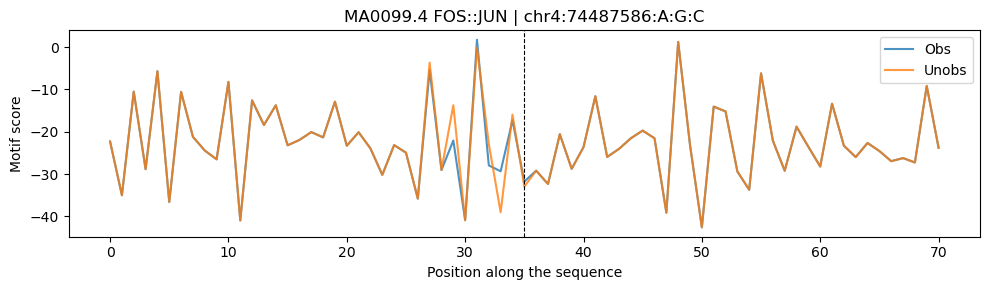

In [26]:
###
plt.figure(figsize=(10,3))
plt.plot(arr_score_obs, label="Obs",   alpha=0.8)
plt.plot(arr_score_ubs, label="Unobs", alpha=0.8)
plt.axvline(35, color="k", linestyle="--", lw=0.8)
plt.legend()
plt.title(f"{txt_motif_target} | {txt_seq_idx}")
plt.xlabel("Position along the sequence")
plt.ylabel("Motif score")
plt.tight_layout()
plt.show()

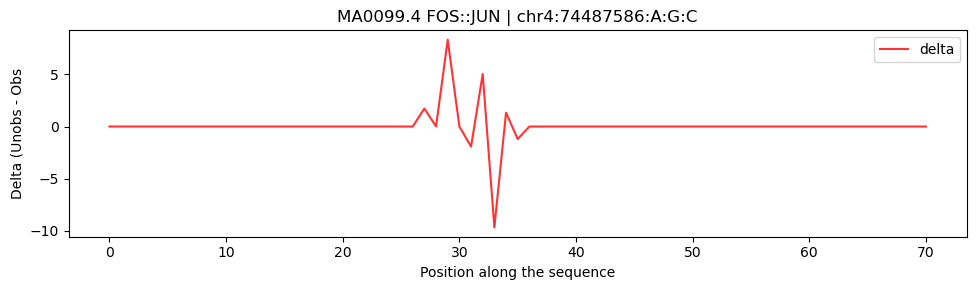

In [28]:
### Plot
plt.figure(figsize=(10,3))
plt.plot(arr_score_delta, label="delta", alpha=0.8, c = "red")
plt.legend()
plt.title(f"{txt_motif_target} | {txt_seq_idx}")
plt.xlabel("Position along the sequence")
plt.ylabel("Delta (Unobs - Obs")
plt.tight_layout()
plt.show()

**Reverse scanning**

In [29]:
### get motif and index
txt_motif_target = "MA0099.4 FOS::JUN"
num_motif_idx    = lst_motif_name.index(txt_motif_target)
num_seq_idx      = 0
txt_seq_idx      = lst_seq_txt_idx[num_seq_idx]
num_strand_idx   = 1 # reverse
print("Motif Name: ", txt_motif_target)
print("Motif Index:", num_motif_idx)

### get the score vectors
arr_score_obs   = arr_motif_scan_obs[num_seq_idx, num_motif_idx, :, num_strand_idx]
arr_score_ubs   = arr_motif_scan_ubs[num_seq_idx, num_motif_idx, :, num_strand_idx]
arr_score_delta = arr_score_ubs - arr_score_obs

Motif Name:  MA0099.4 FOS::JUN
Motif Index: 68


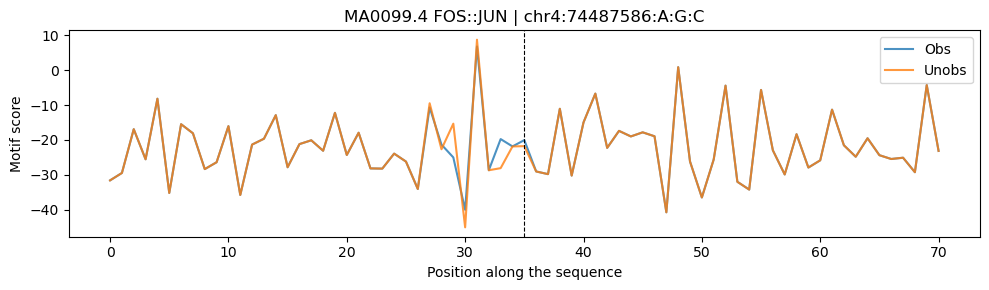

In [30]:
### Plot
plt.figure(figsize=(10,3))
plt.plot(arr_score_obs, label="Obs",   alpha=0.8)
plt.plot(arr_score_ubs, label="Unobs", alpha=0.8)
plt.axvline(35, color="k", linestyle="--", lw=0.8)
plt.legend()
plt.title(f"{txt_motif_target} | {txt_seq_idx}")
plt.xlabel("Position along the sequence")
plt.ylabel("Motif score")
plt.tight_layout()
plt.show()

## Tbind

In [31]:
from scipy.stats import gaussian_kde

In [32]:
txt_motif = "MA0099.4 FOS::JUN"
dct_model = dct_motif_model[txt_motif]

### Extract arrays
arr_num_score_grid = dct_model["arr_num_score_grid"] # x-axis (score values)
arr_num_score_pmf  = dct_model["arr_num_score_pmf"]  # y-axis (probabilities)
arr_num_score_ccdf = dct_model["arr_num_score_ccdf"]

num_Tbind = dct_model["num_Tbind"]         # threshold score
num_alpha = dct_model["num_alpha"]         # tail probability
num_precision = dct_model["num_precision"] # discretization

print(f"{txt_motif} - grid: {arr_num_score_grid.shape}, pmf: {arr_num_score_pmf.shape}")
print(f"Tbind = {num_Tbind:.3f}, α = {num_alpha}, precision = {num_precision}")

MA0099.4 FOS::JUN - grid: (80001,), pmf: (80001,)
Tbind = 5.970, α = 0.001, precision = 0.001


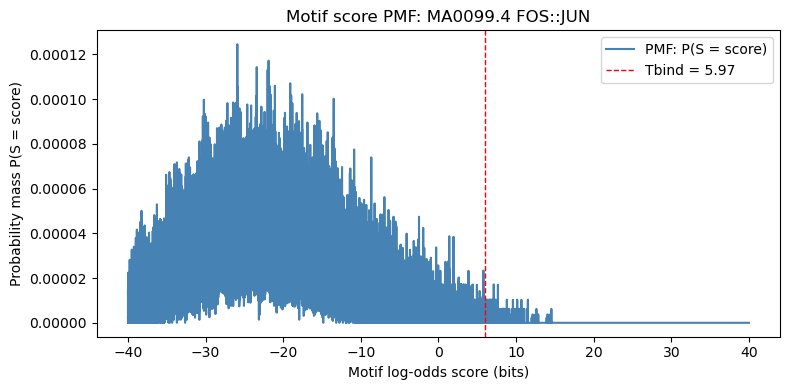

In [33]:
plt.figure(figsize=(8,4))
plt.plot(
    arr_num_score_grid, 
    arr_num_score_pmf, 
    lw=1.5, 
    color="steelblue", 
    label="PMF: P(S = score)")
plt.axvline(num_Tbind, color="red", ls="--", lw=1, label=f"Tbind = {num_Tbind:.2f}")
plt.xlabel("Motif log-odds score (bits)")
plt.ylabel("Probability mass P(S = score)")
plt.title(f"Motif score PMF: {txt_motif}")
plt.legend()
plt.tight_layout()
plt.show()

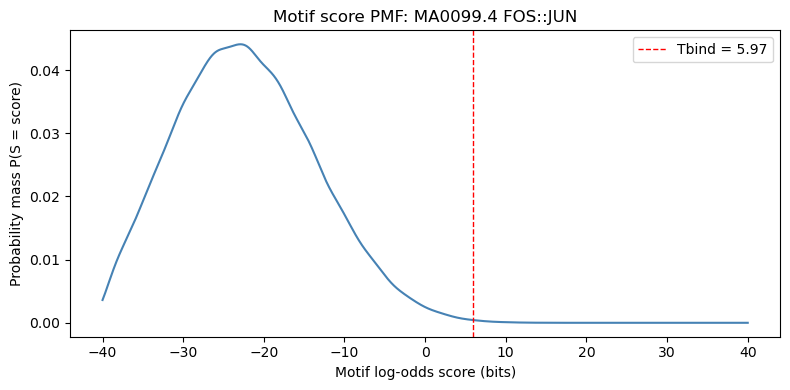

In [34]:
###
kde = gaussian_kde(
    arr_num_score_grid,
    weights=arr_num_score_pmf / arr_num_score_pmf.sum()
)
grid_dense = np.linspace(arr_num_score_grid.min(), arr_num_score_grid.max(), 2000)

###
plt.figure(figsize=(8,4))
plt.plot(grid_dense, kde(grid_dense), color="steelblue")
plt.axvline(num_Tbind, color="red", ls="--", lw=1, label=f"Tbind = {num_Tbind:.2f}")
plt.xlabel("Motif log-odds score (bits)")
plt.ylabel("Probability mass P(S = score)")
plt.title(f"Motif score PMF: {txt_motif}")
plt.legend()
plt.tight_layout()
plt.show()

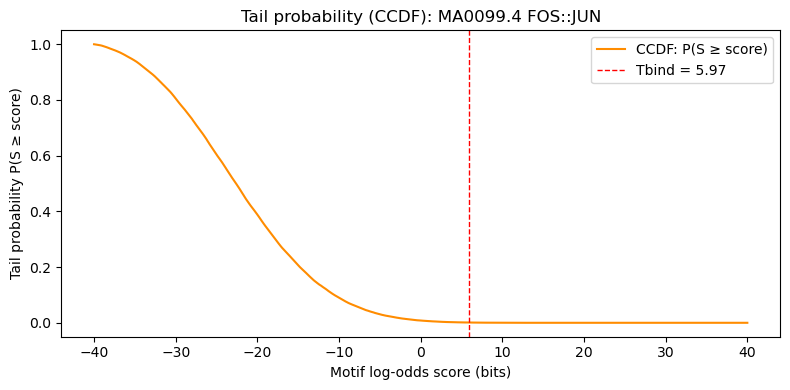

In [35]:
plt.figure(figsize=(8,4))
plt.plot(
    arr_num_score_grid, 
    arr_num_score_ccdf, 
    lw=1.5, 
    color="darkorange", 
    label="CCDF: P(S ≥ score)")
plt.axvline(num_Tbind, color="red", ls="--", lw=1, label=f"Tbind = {num_Tbind:.2f}")
plt.xlabel("Motif log-odds score (bits)")
plt.ylabel("Tail probability P(S ≥ score)")
plt.title(f"Tail probability (CCDF): {txt_motif}")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
idx_tbind = np.argmin(np.abs(arr_num_score_grid - num_Tbind))
print(f"At Tbind = {num_Tbind:.3f}, P(S ≥ T) ≈ {arr_num_score_ccdf[idx_tbind]:.3e}")

At Tbind = 5.970, P(S ≥ T) ≈ 1.001e-03


## Compute raw delta

In [37]:
### raw delta (unobs - obs)
arr_motif_delta = arr_motif_scan_ubs - arr_motif_scan_obs
print("Delta Shape:", arr_motif_delta.shape)

Delta Shape: (100, 879, 71, 2)


## Hard threshold delta using Tbind

In [38]:
lst_motif_name = list(dct_motif_model.keys())
arr_Tbind = np.array([dct_motif_model[txt]["num_Tbind"] for txt in lst_motif_name])

print(f"Tbind range: {np.nanmin(arr_Tbind):.3f} – {np.nanmax(arr_Tbind):.3f}")

Tbind range: -2.329 – 16.667


In [39]:
# reshape Tbind for broadcasting
arr_Tbind_reshape = arr_Tbind[None, :, None, None]  # (1, M, 1, 1)

# boolean mask: motif formed in unobserved allele but not observed
arr_motif_mask_gain = (arr_motif_scan_ubs >= arr_Tbind_reshape) & (arr_motif_scan_obs < arr_Tbind_reshape)

print(arr_motif_mask_gain.shape)
print(f"Motif formation frequency: {arr_motif_mask_gain.mean():.6f}")

(100, 879, 71, 2)
Motif formation frequency: 0.000262


In [40]:
# total count per motif
arr_motif_gain_count = arr_motif_mask_gain.sum(axis=(0, 2, 3))  # (M,)
arr_motif_gain_frac  = arr_motif_mask_gain.mean(axis=(0, 2, 3)) # fraction

# rank top motifs
arr_motif_rank = np.argsort(-arr_motif_gain_count)

print("Top motifs by formation count:")
for i in arr_motif_rank[:20]:
    print(f"{lst_motif_name[i]:25s}  Gain Count ={arr_motif_gain_count[i]:5d}")
    #print(f"{i:4d}  {lst_motif_name[i]:25s}  Gain Count={arr_motif_gain_count[i]:6d}  Fraction={arr_motif_gain_frac[i]:.6e}")

Top motifs by formation count:
MA0639.2 DBP               Gain Count =  130
MA1475.2 CREB3L4           Gain Count =  130
MA0860.1 Rarg              Gain Count =  115
MA1136.1 FOSB::JUNB        Gain Count =  110
MA1139.2 FOSL2::JUNB       Gain Count =   98
MA1134.2 FOS::JUNB         Gain Count =   87
MA1129.1 FOSL1::JUN        Gain Count =   82
MA0837.3 CEBPE             Gain Count =   82
MA1127.1 FOSB::JUN         Gain Count =   82
MA0834.2 ATF7              Gain Count =   72
MA0839.2 CREB3L1           Gain Count =   70
MA1131.2 FOSL2::JUN        Gain Count =   68
MA0604.1 Atf1              Gain Count =   64
MA0025.3 NFIL3             Gain Count =   63
MA0046.3 HNF1A             Gain Count =   59
MA1128.2 FOSL1::JUN        Gain Count =   56
MA0656.2 JDP2              Gain Count =   55
MA0840.2 Creb5             Gain Count =   54
MA1140.3 JUNB              Gain Count =   54
MA1633.2 BACH1             Gain Count =   53


In [42]:
txt_motif = "MA0099.4 FOS::JUN"
idx_motif = lst_motif_name.index(txt_motif)

# Boolean mask for this motif only (N, P, 2)
mask = arr_motif_mask_gain[:, idx_motif, :, :]

# Which variants (sequences) have motif formation anywhere?
variant_idx = np.where(mask.any(axis=(1, 2)))[0]
print(f"{txt_motif}: formed in {len(variant_idx)} / {mask.shape[0]} sequences")

# For the first variant, get the positions and strands
if len(variant_idx) > 0:
    idx_seq = variant_idx[0]
    pos, strand = np.where(mask[idx_seq])
    print(f"Seq {i_seq}: positions {pos}, strands {strand}")
else:
    print("No motif formation events for this motif.")

MA0099.4 FOS::JUN: formed in 0 / 100 sequences
No motif formation events for this motif.


In [43]:
for txt in ["MA0099.4 FOS::JUN", "MA1134.2 FOS::JUNB", "MA1136.1 FOSB::JUNB"]:
    idx = lst_motif_name.index(txt)
    print(f"{txt:25s}  Tbind={arr_Tbind[idx]:.3f}")

MA0099.4 FOS::JUN          Tbind=5.970
MA1134.2 FOS::JUNB         Tbind=5.119
MA1136.1 FOSB::JUNB        Tbind=6.298


In [44]:
for txt in ["MA0099.4 FOS::JUN", "MA1134.2 FOS::JUNB", "MA1136.1 FOSB::JUNB"]:
    idx = lst_motif_name.index(txt)
    hits_obs = (arr_motif_scan_obs[:, idx, :, :] >= arr_Tbind[idx]).sum()
    hits_ubs = (arr_motif_scan_ubs[:, idx, :, :] >= arr_Tbind[idx]).sum()
    print(f"{txt:25s}  obs_hits={hits_obs:6d}  unobs_hits={hits_ubs:6d}")

MA0099.4 FOS::JUN          obs_hits=     8  unobs_hits=     8
MA1134.2 FOS::JUNB         obs_hits=    77  unobs_hits=   164
MA1136.1 FOSB::JUNB        obs_hits=    33  unobs_hits=   143


**Visualize AP-1 (MA0099.4 FOS::JUN)**

In [45]:
# target motif
txt_motif = "MA0099.4 FOS::JUN"
i_motif = lst_motif_name.index(txt_motif)
i_strand = 0

# extract delta for this motif (N, P, 2)
arr_delta_fwd = arr_motif_delta[:, i_motif, :, i_strand]  # forward strand only

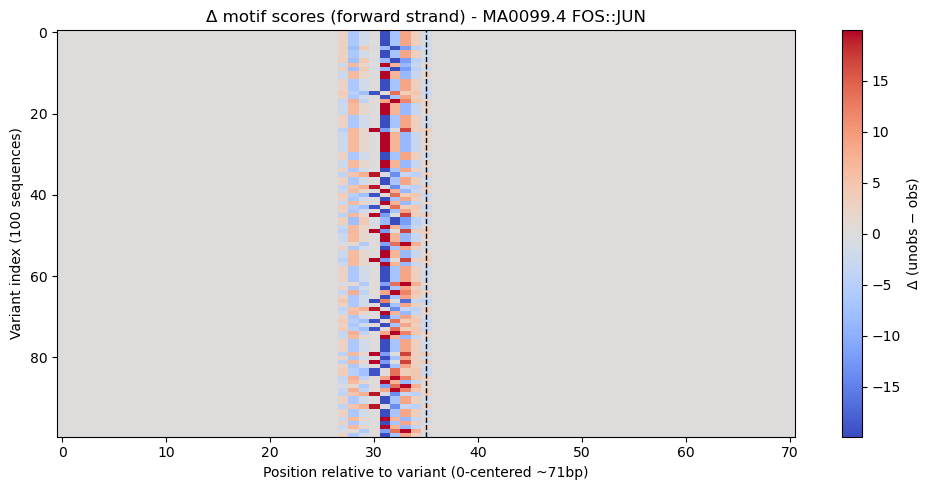

In [46]:
### clip for visual contrast ---
vmax = np.nanpercentile(np.abs(arr_delta_fwd), 99)
vmin = -vmax

### plot delta heatmap (forward strand only) ---
plt.figure(figsize=(10, 5))
plt.imshow(
    arr_delta_fwd,
    aspect='auto',
    cmap='coolwarm',
    interpolation='nearest',
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(label="Δ (unobs − obs)")
plt.axvline(arr_delta_fwd.shape[1]//2, color="black", ls="--", lw=1)
plt.title(f"Δ motif scores (forward strand) - {txt_motif}")
plt.xlabel("Position relative to variant (0-centered ~71bp)")
plt.ylabel("Variant index (100 sequences)")
plt.tight_layout()
plt.show()

In [47]:
### select motif
txt_motif = "MA0099.4 FOS::JUN"
i_motif = lst_motif_name.index(txt_motif)
Tbind = arr_Tbind[i_motif]

### boolean mask for motif formation (forward strand only) 
mask_gain_fwd = (
    (arr_motif_scan_ubs[:, i_motif, :, 0] >= Tbind) &
    (arr_motif_scan_obs[:, i_motif, :, 0] <  Tbind)
)
print(f"Mask shape: {mask_gain_fwd.shape} | gain fraction = {mask_gain_fwd.mean():.6f}")

# --- get Δ (forward strand only) ---
arr_delta_fwd = arr_motif_delta[:, i_motif, :, 0].copy()

# --- mask Δ to show only formation positions ---
arr_delta_fwd_masked = np.where(mask_gain_fwd, arr_delta_fwd, np.nan)

Mask shape: (100, 71) | gain fraction = 0.000000


/opt/conda/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


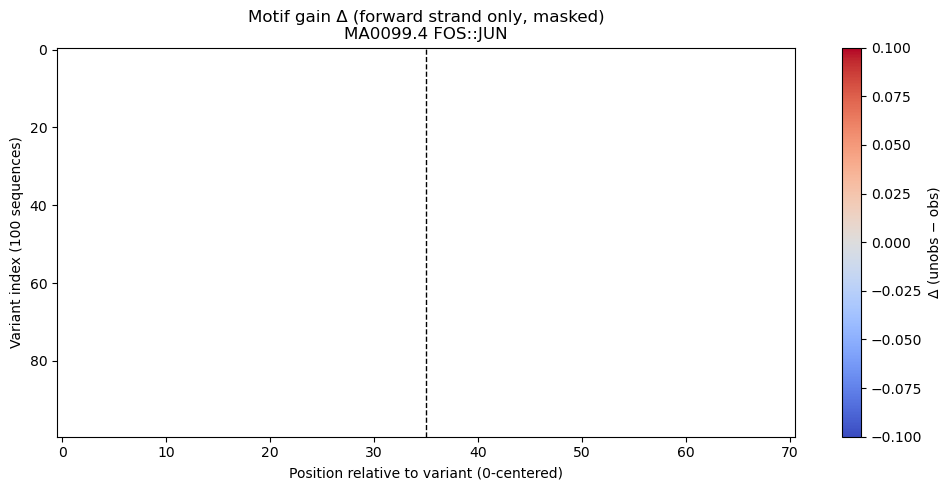

In [48]:
### optional: clip for visual contrast ---
vmax = np.nanpercentile(np.abs(arr_delta_fwd_masked), 99)
vmin = -vmax

### plot masked Δ heatmap (forward strand only) ---
plt.figure(figsize=(10,5))
plt.imshow(
    arr_delta_fwd_masked,
    aspect='auto',
    cmap='coolwarm',
    interpolation='nearest',
    vmin=vmin, vmax=vmax
)
plt.colorbar(label="Δ (unobs − obs)")
plt.axvline(arr_delta_fwd_masked.shape[1]//2, color="black", ls="--", lw=1)
plt.title(f"Motif gain Δ (forward strand only, masked)\n{txt_motif}")
plt.xlabel("Position relative to variant (0-centered)")
plt.ylabel("Variant index (100 sequences)")
plt.tight_layout()
plt.show()

**Visualize AP-1 (MA1136.1 FOSB::JUNB)**

In [50]:
# --- target motif ---
txt_motif = "MA1136.1 FOSB::JUNB"
i_motif = lst_motif_name.index(txt_motif)
i_strand = 0

# --- extract Δ for this motif (N, P, 2)
arr_delta_fwd = arr_motif_delta[:, i_motif, :, i_strand]  # forward strand only

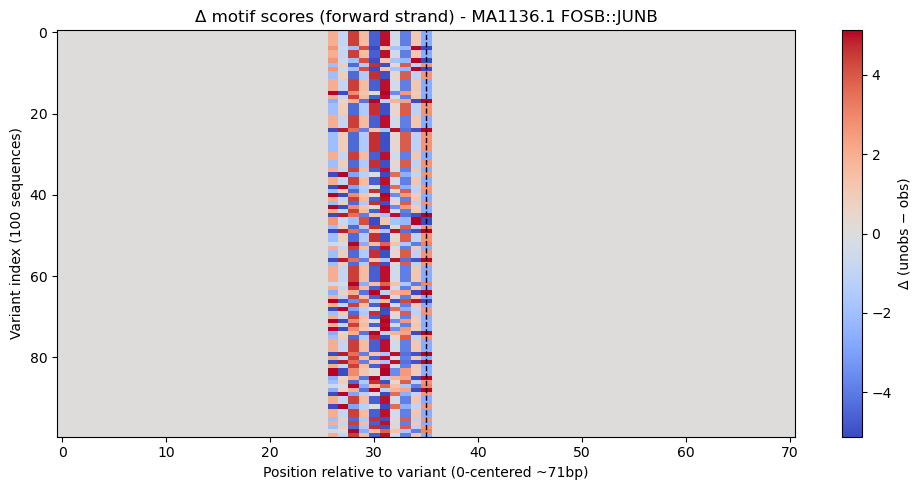

In [51]:
# --- optional: clip for visual contrast ---
vmax = np.nanpercentile(np.abs(arr_delta_fwd), 99)
vmin = -vmax

# --- plot Δ heatmap (forward strand only) ---
plt.figure(figsize=(10, 5))
plt.imshow(
    arr_delta_fwd,
    aspect='auto',
    cmap='coolwarm',
    interpolation='nearest',
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(label="Δ (unobs − obs)")
plt.axvline(arr_delta_fwd.shape[1]//2, color="black", ls="--", lw=1)
plt.title(f"Δ motif scores (forward strand) - {txt_motif}")
plt.xlabel("Position relative to variant (0-centered ~71bp)")
plt.ylabel("Variant index (100 sequences)")
plt.tight_layout()
plt.show()

In [52]:
# --- select motif ---
txt_motif = "MA1136.1 FOSB::JUNB"
i_motif = lst_motif_name.index(txt_motif)
Tbind = arr_Tbind[i_motif]

# --- boolean mask for motif formation (forward strand only) ---
mask_gain_fwd = (
    (arr_motif_scan_ubs[:, i_motif, :, 0] >= Tbind) &
    (arr_motif_scan_obs[:, i_motif, :, 0] <  Tbind)
)
print(f"Mask shape: {mask_gain_fwd.shape} | gain fraction = {mask_gain_fwd.mean():.6f}")

# --- get Δ (forward strand only) ---
arr_delta_fwd = arr_motif_delta[:, i_motif, :, 0].copy()

# --- mask Δ to show only formation positions ---
arr_delta_fwd_masked = np.where(mask_gain_fwd, arr_delta_fwd, np.nan)

Mask shape: (100, 71) | gain fraction = 0.008028


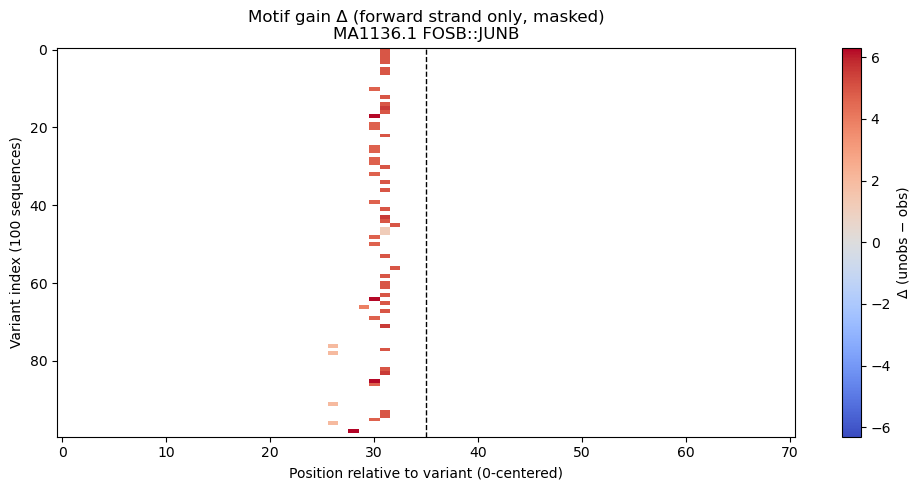

In [53]:
# --- optional: clip for visual contrast ---
vmax = np.nanpercentile(np.abs(arr_delta_fwd_masked), 99)
vmin = -vmax

# --- plot masked Δ heatmap (forward strand only) ---
plt.figure(figsize=(10,5))
plt.imshow(
    arr_delta_fwd_masked,
    aspect='auto',
    cmap='coolwarm',
    interpolation='nearest',
    vmin=vmin, vmax=vmax
)
plt.colorbar(label="Δ (unobs − obs)")
plt.axvline(arr_delta_fwd_masked.shape[1]//2, color="black", ls="--", lw=1)
plt.title(f"Motif gain Δ (forward strand only, masked)\n{txt_motif}")
plt.xlabel("Position relative to variant (0-centered)")
plt.ylabel("Variant index (100 sequences)")
plt.tight_layout()
plt.show()

In [54]:
# --- maximum Δ and its index per variant (robust version) ---
arr_delta_max = np.full(arr_delta_fwd_masked.shape[0], np.nan)
arr_delta_argmax = np.full(arr_delta_fwd_masked.shape[0], np.nan)

for i in range(arr_delta_fwd_masked.shape[0]):
    arr_i = arr_delta_fwd_masked[i]
    if np.any(np.isfinite(arr_i)):
        arr_delta_max[i] = np.nanmax(arr_i)
        arr_delta_argmax[i] = np.nanargmax(arr_i)

# --- mask variants with actual motif gain ---
mask_valid = np.isfinite(arr_delta_max)

print(f"Motif gain detected in {mask_valid.sum()} / {mask_valid.size} variants")

# --- subset arrays ---
delta_max = arr_delta_max[mask_valid]
pos_max = arr_delta_argmax[mask_valid].astype(int)
variant_idx = np.where(mask_valid)[0]

# --- center offset (distance from variant position) ---
center = arr_delta_fwd_masked.shape[1] // 2
offset_max = pos_max - center

# --- summary ---
print("Example motif gain peaks (forward strand):")
for j in range(min(10, len(delta_max))):
    print(f"Seq {variant_idx[j]:3d}  pos={pos_max[j]:2d}  (offset={offset_max[j]:+2d})  Δ={delta_max[j]:.3f}")

Motif gain detected in 57 / 100 variants
Example motif gain peaks (forward strand):
Seq   0  pos=31  (offset=-4)  Δ=4.970
Seq   1  pos=31  (offset=-4)  Δ=4.970
Seq   2  pos=31  (offset=-4)  Δ=4.970
Seq   3  pos=31  (offset=-4)  Δ=4.970
Seq   5  pos=31  (offset=-4)  Δ=4.970
Seq   6  pos=31  (offset=-4)  Δ=4.970
Seq  10  pos=30  (offset=-5)  Δ=4.666
Seq  12  pos=31  (offset=-4)  Δ=4.970
Seq  14  pos=31  (offset=-4)  Δ=4.970
Seq  15  pos=31  (offset=-4)  Δ=5.537


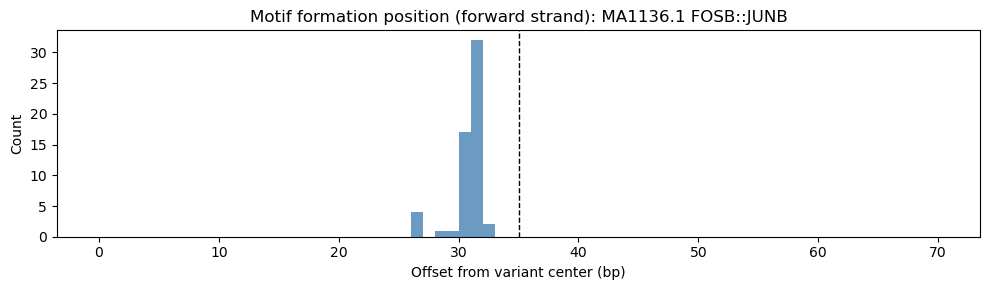

In [55]:
plt.figure(figsize=(10,3))
#plt.hist(offset_max, bins=np.arange(-35,36), color="steelblue", alpha=0.8)
plt.hist(pos_max, bins=np.arange(0,71), color="steelblue", alpha=0.8)
plt.axvline(35, color="black", ls="--", lw=1)
plt.title(f"Motif formation position (forward strand): {txt_motif}")
plt.xlabel("Offset from variant center (bp)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Visualize the motif and sequence

In [56]:
### set file directory
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard")
#txt_fname = "variant_closed_gof_bluestarr_withseq_flank35.tsv.gz"
txt_fname = "variant_closed_gof_bluestarr_withseq_flank35.tsv.gz"
txt_fpath = os.path.join(txt_fdiry, txt_fname)

### read table
dat = pd.read_csv(txt_fpath, sep = "\t")

### assign and show
dat_variant_withseq = dat
print(dat.shape)
dat.head()

(1884977, 17)


,Chrom,ChromStart,ChromEnd,Region,Variant_ID,Pos0,Ref,Obs,Unobs,Delta,Flank,Interval,Seq_Length,Seq_Ref,Seq_Obs,Seq_Unobs,Check_RefMatch
0,chr4,74487576,74488141,chr4:74487576-74488141,chr4:74487586:A:G:C,74487586,A,G,C,0.964984,35,chr4:74487551-74487622,71,ACATGTGTGTATGCTTGTCTATATACACTGTATGAAGCAAGAGGAG...,ACATGTGTGTATGCTTGTCTATATACACTGTATGAGGCAAGAGGAG...,ACATGTGTGTATGCTTGTCTATATACACTGTATGACGCAAGAGGAG...,True
1,chr9,135685425,135685942,chr9:135685425-135685942,chr9:135685432:G:G:C,135685432,G,G,C,0.945423,35,chr9:135685397-135685468,71,CCGGGGACACATCCCCCAGGAAACCTCTGGGCTGAGGCAACACCAA...,CCGGGGACACATCCCCCAGGAAACCTCTGGGCTGAGGCAACACCAA...,CCGGGGACACATCCCCCAGGAAACCTCTGGGCTGACGCAACACCAA...,True
2,chr1,173251481,173251541,chr1:173251481-173251541,chr1:173251490:G:G:C,173251490,G,G,C,0.910127,35,chr1:173251455-173251526,71,ACATAGTACTCAATACCTATTTGGTGAATAGATGAGGCAATCTCAC...,ACATAGTACTCAATACCTATTTGGTGAATAGATGAGGCAATCTCAC...,ACATAGTACTCAATACCTATTTGGTGAATAGATGACGCAATCTCAC...,True
3,chr1,147523084,147523503,chr1:147523084-147523503,chr1:147523391:G:G:C,147523391,G,G,C,0.908800,35,chr1:147523356-147523427,71,ATTTTTAAAAGTTCAGGTAGTTTAAAGATGGCTGAGGCAATGCAAT...,ATTTTTAAAAGTTCAGGTAGTTTAAAGATGGCTGAGGCAATGCAAT...,ATTTTTAAAAGTTCAGGTAGTTTAAAGATGGCTGACGCAATGCAAT...,True
4,chr18,54580694,54581420,chr18:54580694-54581420,chr18:54580749:A:G:T,54580749,A,G,T,0.862296,35,chr18:54580714-54580785,71,TGTTTAGCTAACAGAAATACTTCAGCAGAGCCTGAAGCAATGGCCA...,TGTTTAGCTAACAGAAATACTTCAGCAGAGCCTGAGGCAATGGCCA...,TGTTTAGCTAACAGAAATACTTCAGCAGAGCCTGATGCAATGGCCA...,True


In [59]:
# --- collect top motif-gain hits ---
top_n = 10
top_order = np.argsort(-delta_max)[:top_n]

records = []
for rank, j in enumerate(top_order, start=1):
    i_seq = variant_idx[j]
    pos = int(pos_max[j])
    offset = int(offset_max[j])
    Δ = float(delta_max[j])
    row = dat.iloc[i_seq]

    records.append({
        "Rank": rank,
        "Variant_Index": i_seq,
        "Variant_ID": row["Variant_ID"],
        "Chrom": row["Chrom"],
        "Pos0": row["Pos0"],
        "Ref": row["Ref"],
        "Obs": row["Obs"],
        "Unobs": row["Unobs"],
        "Δ_max": Δ,
        "Pos_max": pos,
        "Offset": offset
    })

df_top_gain = pd.DataFrame(records)
print(df_top_gain)

   Rank  Variant_Index             Variant_ID  Chrom       Pos0 Ref Obs Unobs  \
0     1             98   chr16:22161239:G:T:C  chr16   22161239   G   T     C   
1     2             85   chr4:146251795:C:T:G   chr4  146251795   C   T     G   
2     3             17   chr15:80030566:C:T:G  chr15   80030566   C   T     G   
3     4             64    chr7:93962227:C:T:G   chr7   93962227   C   T     G   
4     5             71   chr15:82049561:G:A:C  chr15   82049561   G   A     C   
5     6             15    chr1:16238967:A:A:C   chr1   16238967   A   A     C   
6     7             43    chr3:88300638:G:A:C   chr3   88300638   G   A     C   
7     8             83    chr5:69156320:A:A:C   chr5   69156320   A   A     C   
8     9             63  chr11:125438423:A:G:C  chr11  125438423   A   G     C   
9    10             67   chr2:138843691:G:G:C   chr2  138843691   G   G     C   

      Δ_max  Pos_max  Offset  
0  6.428471       28      -7  
1  6.208427       30      -5  
2  6.208426    

<Figure size 600x200 with 0 Axes>

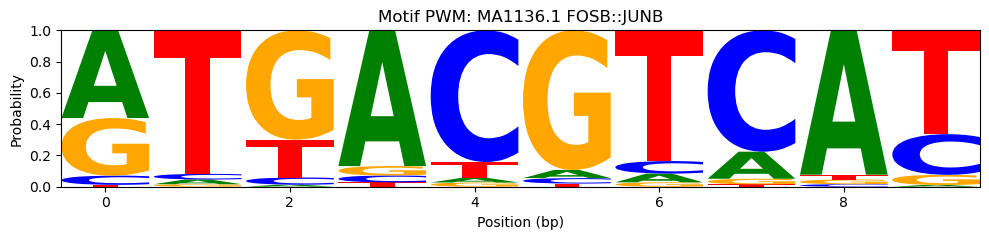

In [61]:
txt_motif = "MA1136.1 FOSB::JUNB"

# get PWM (normalized probabilities)
arr_pwm = dct_motif_pwms[txt_motif]  # (W, 4)
arr_pwm = arr_pwm / arr_pwm.sum(axis=1, keepdims=True)

# convert to DataFrame
df_pwm = pd.DataFrame(arr_pwm, columns=list("ACGT"))

# plot motif logo
plt.figure(figsize=(6,2))
logomaker.Logo(df_pwm, color_scheme="classic")
plt.title(f"Motif PWM: {txt_motif}")
plt.xlabel("Position (bp)")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

In [65]:
i_row = 0  # top variant
row = df_top_gain.iloc[i_row]
print(row)

Rank                                1
Variant_Index                      98
Variant_ID       chr16:22161239:G:T:C
Chrom                           chr16
Pos0                         22161239
Ref                                 G
Obs                                 T
Unobs                               C
Δ_max                        6.428471
Pos_max                            28
Offset                             -7
Name: 0, dtype: object


### Plot sequence alignment

In [79]:
i_row = 0  # top variant
row = df_top_gain.iloc[i_row]
pos = row["Pos_max"]
k = 10  # ±10 bp around motif formation site

variant = dat.iloc[row["Variant_Index"]]
seq_obs  = variant["Seq_Obs"][pos-k : pos+k+1]
seq_unobs = variant["Seq_Unobs"][pos-k : pos+k+1]

print(f"Variant: {row['Variant_ID']}")
print(f"Obs:  {seq_obs}")
print(f"Unobs:{seq_unobs}")

Variant: chr16:22161239:G:T:C
Obs:  TCAAAATAGAATGATGTTATT
Unobs:TCAAAATAGAATGATGTCATT


In [80]:
i_row = 0  # top variant
row = df_top_gain.iloc[i_row]
pos = row["Pos_max"]
pos += 7
k = 10  # ±10 bp around motif formation site

variant = dat.iloc[row["Variant_Index"]]
seq_obs  = variant["Seq_Obs"][pos-k : pos+k+1]
seq_unobs = variant["Seq_Unobs"][pos-k : pos+k+1]

print(f"Variant: {row['Variant_ID']}")
print(f"Obs:  {seq_obs}")
print(f"Unobs:{seq_unobs}")

Variant: chr16:22161239:G:T:C
Obs:  AGAATGATGTTATTGATGCAT
Unobs:AGAATGATGTCATTGATGCAT


```
Variant: chr16:22161239:G:T:C
Obs:  TCAAAATAGAATGATGTTATT
Unobs:TCAAAATAGAATGATGTCATT
```

In [82]:
i_row = 0  # top variant
row = df_top_gain.iloc[i_row]
pos = row["Pos_max"]
k = 10  # ±10 bp around motif formation site

variant = dat.iloc[row["Variant_Index"]]
seq_obs  = variant["Seq_Obs"][pos-k : pos+k+1]
seq_unobs = variant["Seq_Unobs"][pos-k : pos+k+1]

print(f"Variant: {row['Variant_ID']}")
print(f"Obs:  {seq_obs}")
print(f"Unobs:{seq_unobs}")

Variant: chr16:22161239:G:T:C
Obs:  TCAAAATAGAATGATGTTATT
Unobs:TCAAAATAGAATGATGTCATT


Variant index in local window: 17


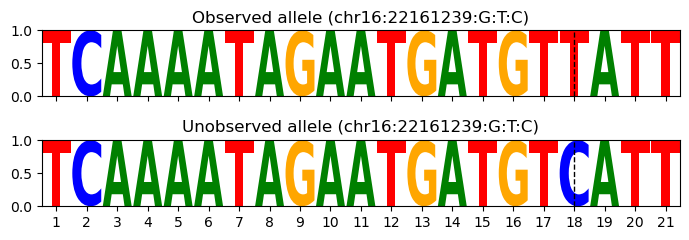

In [83]:
def seq_to_df(seq):
    """Convert string sequence to one-hot DataFrame (A,C,G,T)."""
    alphabet = "ACGT"
    arr = np.zeros((len(seq), 4))
    for i, base in enumerate(seq.upper()):
        if base in alphabet:
            arr[i, alphabet.index(base)] = 1
    return pd.DataFrame(arr, columns=list("ACGT"))

# Variant center in full sequence (flank=35)
center = 35

# Define integer tick positions
x_positions = np.arange(seq_len)
x_labels = x_positions + 1  # show 1-based coordinates if you prefer

# Variant position relative to this smaller extracted window
variant_pos_local = k + (center - pos)
print(f"Variant index in local window: {variant_pos_local}")

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(7, 2.5), sharex=True)

# Observed allele
ax = axes[0]
logomaker.Logo(seq_to_df(seq_obs), color_scheme="classic", ax=ax)
ax.set_title(f"Observed allele ({row['Variant_ID']})")
ax.axvline(variant_pos_local, color="black", lw=1, ls="--")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
#ax.text(variant_pos_local+0.5, 0.9, "variant", color="red", fontsize=8, va="top")

# Unobserved allele
ax = axes[1]
logomaker.Logo(seq_to_df(seq_unobs), color_scheme="classic", ax=ax)
ax.set_title(f"Unobserved allele ({row['Variant_ID']})")
ax.axvline(variant_pos_local, color="black", lw=1, ls="--")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
#ax.text(variant_pos_local+0.5, 0.9, "variant", color="red", fontsize=8, va="top")

plt.tight_layout()
plt.show()

```
Variant: chr16:22161239:G:T:C
Obs:  AGAATGATGTTATTGATGCAT
Unobs:AGAATGATGTCATTGATGCAT
```

In [84]:
i_row = 0  # top variant
row = df_top_gain.iloc[i_row]
pos = row["Pos_max"]
pos += 7
k = 10  # ±10 bp around motif formation site

variant = dat.iloc[row["Variant_Index"]]
seq_obs  = variant["Seq_Obs"][pos-k : pos+k+1]
seq_unobs = variant["Seq_Unobs"][pos-k : pos+k+1]

print(f"Variant: {row['Variant_ID']}")
print(f"Obs:  {seq_obs}")
print(f"Unobs:{seq_unobs}")

Variant: chr16:22161239:G:T:C
Obs:  AGAATGATGTTATTGATGCAT
Unobs:AGAATGATGTCATTGATGCAT


Variant index in local window: 10


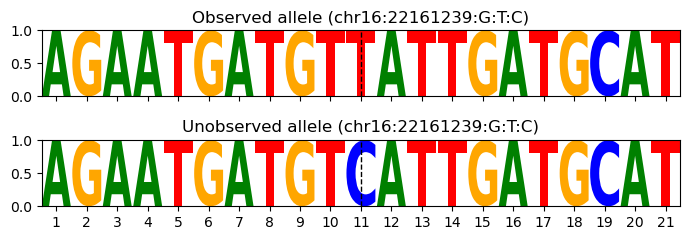

In [85]:
def seq_to_df(seq):
    """Convert string sequence to one-hot DataFrame (A,C,G,T)."""
    alphabet = "ACGT"
    arr = np.zeros((len(seq), 4))
    for i, base in enumerate(seq.upper()):
        if base in alphabet:
            arr[i, alphabet.index(base)] = 1
    return pd.DataFrame(arr, columns=list("ACGT"))

# Variant center in full sequence (flank=35)
center = 35

# Define integer tick positions
x_positions = np.arange(seq_len)
x_labels = x_positions + 1  # show 1-based coordinates if you prefer

# Variant position relative to this smaller extracted window
variant_pos_local = k + (center - pos)
print(f"Variant index in local window: {variant_pos_local}")

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(7, 2.5), sharex=True)

# Observed allele
ax = axes[0]
logomaker.Logo(seq_to_df(seq_obs), color_scheme="classic", ax=ax)
ax.set_title(f"Observed allele ({row['Variant_ID']})")
ax.axvline(variant_pos_local, color="black", lw=1, ls="--")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
#ax.text(variant_pos_local+0.5, 0.9, "variant", color="red", fontsize=8, va="top")

# Unobserved allele
ax = axes[1]
logomaker.Logo(seq_to_df(seq_unobs), color_scheme="classic", ax=ax)
ax.set_title(f"Unobserved allele ({row['Variant_ID']})")
ax.axvline(variant_pos_local, color="black", lw=1, ls="--")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
#ax.text(variant_pos_local+0.5, 0.9, "variant", color="red", fontsize=8, va="top")

plt.tight_layout()
plt.show()

Motif padded to match sequence length: (21, 4)


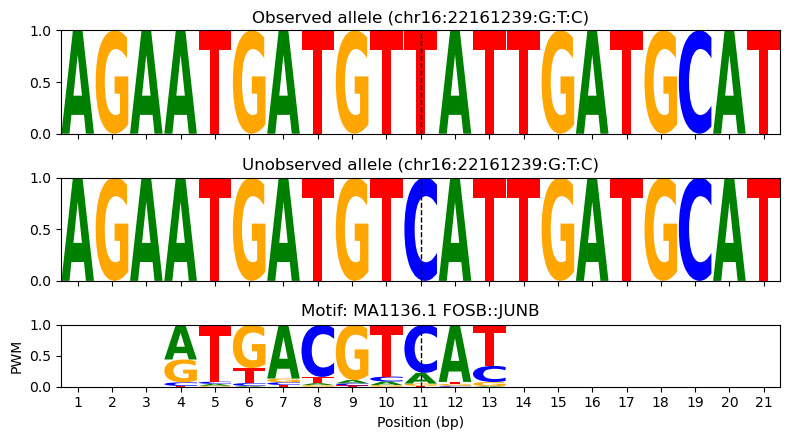

In [97]:
# ---------------------------------------------------------------
# Sequences and motif (example)
# ---------------------------------------------------------------
i_row = 0  # top variant
row = df_top_gain.iloc[i_row]
pos = row["Pos_max"]
pos += 7
k = 10  # ±10 bp around motif formation site

variant = dat.iloc[row["Variant_Index"]]
seq_obs  = variant["Seq_Obs"][pos-k : pos+k+1]
seq_unobs = variant["Seq_Unobs"][pos-k : pos+k+1]

#seq_obs   = "TCAAAATAGAATGATGTTATT"
#seq_unobs = "TCAAAATAGAATGATGTCATT"
txt_motif = "MA1136.1 FOSB::JUNB"

# Motif PWM (W,4)
arr_pwm = dct_motif_pwms[txt_motif]
arr_pwm = arr_pwm / arr_pwm.sum(axis=1, keepdims=True)
motif_df = pd.DataFrame(arr_pwm, columns=list("ACGT"))

# ---------------------------------------------------------------
# Alignment parameters
# ---------------------------------------------------------------
motif_start = 10-7     # where motif should start (0-based in local window)
motif_len   = arr_pwm.shape[0]
seq_len     = len(seq_obs)
motif_pad_left  = motif_start
motif_pad_right = seq_len - motif_len - motif_pad_left

# Pad motif with zero rows (white blanks)
motif_df_padded = pd.concat([
    pd.DataFrame(0, index=np.arange(motif_pad_left), columns=list("ACGT")),
    motif_df,
    pd.DataFrame(0, index=np.arange(motif_pad_right), columns=list("ACGT"))
], ignore_index=True)

print(f"Motif padded to match sequence length: {motif_df_padded.shape}")

# Variant position (for dashed line)
#variant_pos_local = 28
variant_pos_local = 10 

# ---------------------------------------------------------------
# Create figure with 3 aligned tracks
# ---------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(8, 4.5), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1, 0.6]})

# Define integer tick positions
x_positions = np.arange(seq_len)
x_labels = x_positions + 1  # show 1-based coordinates if you prefer

# (1) Observed
ax = axes[0]
logomaker.Logo(seq_to_df(seq_obs), color_scheme="classic", ax=ax)
ax.set_title("Observed allele (chr16:22161239:G:T:C)")
ax.axvline(variant_pos_local, color="black", lw=1, ls="--")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# (2) Unobserved
ax = axes[1]
logomaker.Logo(seq_to_df(seq_unobs), color_scheme="classic", ax=ax)
ax.set_title("Unobserved allele (chr16:22161239:G:T:C)")
ax.axvline(variant_pos_local, color="black", lw=1, ls="--")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# (3) Motif logo (aligned)
ax = axes[2]
logomaker.Logo(motif_df_padded, color_scheme="classic", ax=ax)
ax.axvline(variant_pos_local, color="black", lw=1, ls="--")
ax.set_title(f"Motif: {txt_motif}")
ax.set_ylabel("PWM")
ax.set_xlabel("Position (bp)")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

plt.tight_layout()
txt_fname = "fig.variant_motif.gain_event.seq_logo.chr16_22161239_MA1136.1"
plt.savefig(txt_fname + ".png", dpi=300, bbox_inches="tight")
plt.savefig(txt_fname + ".svg", bbox_inches="tight")
plt.show()

```
Variant: chr16:22161239:G:T:C
Obs:  TCAAAATAGAATGATGTTATT
Unobs:TCAAAATAGAATGATGTCATT
Motif:----------ATGACGTCAT-
```

In [70]:
i_row = 0  # top variant
row = df_top_gain.iloc[i_row]
pos = row["Pos_max"]
k = 10  # ±10 bp around motif formation site

variant = dat.iloc[row["Variant_Index"]]
seq_obs  = variant["Seq_Obs"][pos-k : pos+k+1]
seq_unobs = variant["Seq_Unobs"][pos-k : pos+k+1]

print(f"Variant: {row['Variant_ID']}")
print(f"Obs:  {seq_obs}")
print(f"Unobs:{seq_unobs}")


Variant: chr16:22161239:G:T:C
Obs:  TCAAAATAGAATGATGTTATT
Unobs:TCAAAATAGAATGATGTCATT


Variant index in local window: 10


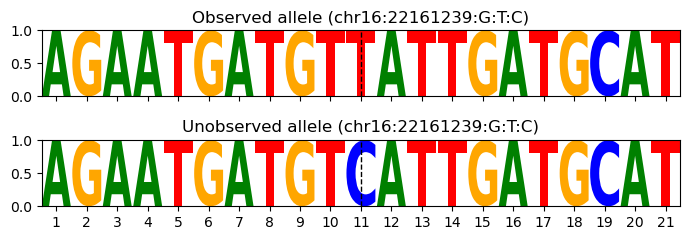

In [91]:
def seq_to_df(seq):
    """Convert string sequence to one-hot DataFrame (A,C,G,T)."""
    alphabet = "ACGT"
    arr = np.zeros((len(seq), 4))
    for i, base in enumerate(seq.upper()):
        if base in alphabet:
            arr[i, alphabet.index(base)] = 1
    return pd.DataFrame(arr, columns=list("ACGT"))

# Variant center in full sequence (flank=35)
center = 35

# Define integer tick positions
x_positions = np.arange(seq_len)
x_labels = x_positions + 1  # show 1-based coordinates if you prefer

# Variant position relative to this smaller extracted window
variant_pos_local = k + (center - pos)
print(f"Variant index in local window: {variant_pos_local}")

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(7, 2.5), sharex=True)

# Observed allele
ax = axes[0]
logomaker.Logo(seq_to_df(seq_obs), color_scheme="classic", ax=ax)
ax.set_title(f"Observed allele ({row['Variant_ID']})")
ax.axvline(variant_pos_local, color="black", lw=1, ls="--")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
#ax.text(variant_pos_local+0.5, 0.9, "variant", color="red", fontsize=8, va="top")

# Unobserved allele
ax = axes[1]
logomaker.Logo(seq_to_df(seq_unobs), color_scheme="classic", ax=ax)
ax.set_title(f"Unobserved allele ({row['Variant_ID']})")
ax.axvline(variant_pos_local, color="black", lw=1, ls="--")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
#ax.text(variant_pos_local+0.5, 0.9, "variant", color="red", fontsize=8, va="top")

plt.tight_layout()
plt.show()

Motif padded to match sequence length: (21, 4)


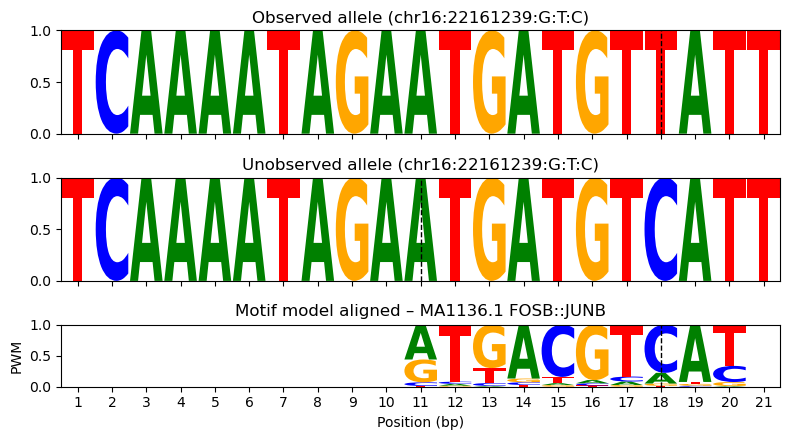

In [92]:
# ---------------------------------------------------------------
# Sequences and motif (example)
# ---------------------------------------------------------------
seq_obs   = "TCAAAATAGAATGATGTTATT"
seq_unobs = "TCAAAATAGAATGATGTCATT"
txt_motif = "MA1136.1 FOSB::JUNB"

# Motif PWM (W,4)
arr_pwm = dct_motif_pwms[txt_motif]
arr_pwm = arr_pwm / arr_pwm.sum(axis=1, keepdims=True)
motif_df = pd.DataFrame(arr_pwm, columns=list("ACGT"))

# ---------------------------------------------------------------
# Alignment parameters
# ---------------------------------------------------------------
motif_start = 10     # where motif should start (0-based in local window)
motif_len   = arr_pwm.shape[0]
seq_len     = len(seq_obs)
motif_pad_left  = motif_start
motif_pad_right = seq_len - motif_len - motif_pad_left

# Pad motif with zero rows (white blanks)
motif_df_padded = pd.concat([
    pd.DataFrame(0, index=np.arange(motif_pad_left), columns=list("ACGT")),
    motif_df,
    pd.DataFrame(0, index=np.arange(motif_pad_right), columns=list("ACGT"))
], ignore_index=True)

print(f"Motif padded to match sequence length: {motif_df_padded.shape}")

# Variant position (for dashed line)
variant_pos_local = 17  # the T→C site in the example

# ---------------------------------------------------------------
# Create figure with 3 aligned tracks
# ---------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(8, 4.5), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1, 0.6]})

# Define integer tick positions
x_positions = np.arange(seq_len)
x_labels = x_positions + 1  # show 1-based coordinates if you prefer

# (1) Observed
ax = axes[0]
logomaker.Logo(seq_to_df(seq_obs), color_scheme="classic", ax=ax)
ax.set_title("Observed allele (chr16:22161239:G:T:C)")
ax.axvline(variant_pos_local, color="black", lw=1, ls="--")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# (2) Unobserved
ax = axes[1]
logomaker.Logo(seq_to_df(seq_unobs), color_scheme="classic", ax=ax)
ax.set_title("Unobserved allele (chr16:22161239:G:T:C)")
ax.axvline(variant_pos_local, color="black", lw=1, ls="--")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# (3) Motif logo (aligned)
ax = axes[2]
logomaker.Logo(motif_df_padded, color_scheme="classic", ax=ax)
ax.axvline(variant_pos_local, color="black", lw=1, ls="--")
ax.set_title(f"Motif model aligned – {txt_motif}")
ax.set_ylabel("PWM")
ax.set_xlabel("Position (bp)")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

plt.tight_layout()
plt.show()